# Speculative Decoding from Scratch — Solution

Build order:
1. **Stage 1** — Baseline greedy decoding (no `model.generate()`)
2. **Stage 2** — Core speculative decoding loop
3. **Stage 3** — Metrics & correctness verification
4. **Stage 4** — Code edit workload adaptation

## Setup

In [1]:
!pip install transformers torch --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import torch
import torch.nn.functional as F
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
DRAFT_MODEL_NAME = "gpt2"
TARGET_MODEL_NAME = "gpt2-xl"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("Loading draft model...")
draft_model = AutoModelForCausalLM.from_pretrained(DRAFT_MODEL_NAME).to(device).eval()

print("Loading target model...")
target_model = AutoModelForCausalLM.from_pretrained(TARGET_MODEL_NAME).to(device).eval()

print(f"Draft params:  {sum(p.numel() for p in draft_model.parameters()):,}")
print(f"Target params: {sum(p.numel() for p in target_model.parameters()):,}")

Loading tokenizer...


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading target model...


model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Draft params:  124,439,808
Target params: 1,557,611,200


---
## Stage 1 — Baseline Autoregressive Decoding

In [4]:
def greedy_decode(
    model,
    input_ids: torch.Tensor,
    max_new_tokens: int = 50,
) -> tuple[torch.Tensor, float]:
    """
    Greedy autoregressive decoding with KV cache.
    Returns (output_ids, tokens_per_second).
    """
    generated = input_ids.clone()
    past_key_values = None
    t0 = time.time()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # On first pass feed full sequence; after that feed only last token
            model_input = generated if past_key_values is None else generated[:, -1:]

            outputs = model(
                model_input,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values

            # logits: [1, seq_len, vocab] — only last position matters
            next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]
            generated = torch.cat([generated, next_token], dim=-1)

    elapsed = time.time() - t0
    tps = max_new_tokens / elapsed
    return generated, tps

In [5]:
prompt = "The capital of France is"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

output_ids, tps = greedy_decode(draft_model, input_ids, max_new_tokens=20)
print(tokenizer.decode(output_ids[0]))
print(f"Draft model: {tps:.1f} tok/s")

output_ids, tps = greedy_decode(target_model, input_ids, max_new_tokens=20)
print(tokenizer.decode(output_ids[0]))
print(f"Target model: {tps:.1f} tok/s")

The capital of France is the capital of the French Republic, and the capital of the French Republic is the capital of the French
Draft model: 42.6 tok/s
The capital of France is the city of Paris. It is the capital of France and the largest city in France. It is
Target model: 26.8 tok/s


---
## Stage 2 — Speculative Decoding

### 2a — Draft: generate k tokens autoregressively

In [6]:
def draft_autoregressive(
    draft_model,
    input_ids: torch.Tensor,   # [1, seq_len]
    k: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Run draft model autoregressively to produce k candidate tokens.

    Returns:
      draft_tokens: [k]        integer token ids
      draft_probs:  [k, vocab] probability distribution at each step

    We save the full softmax distribution (not just argmax) because
    the rejection step needs p_draft(xᵢ) for each accepted token.
    """
    draft_tokens = []
    draft_probs = []
    past_key_values = None
    current_ids = input_ids.clone()

    with torch.no_grad():
        for _ in range(k):
            model_input = current_ids if past_key_values is None else current_ids[:, -1:]

            outputs = draft_model(
                model_input,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values

            # Full probability distribution at the last position
            logits = outputs.logits[:, -1, :]        # [1, vocab]
            probs = F.softmax(logits, dim=-1)[0]     # [vocab]

            # Greedy token selection
            next_token = probs.argmax()              # scalar tensor

            draft_tokens.append(next_token)
            draft_probs.append(probs)

            # Append to running sequence for next iteration
            current_ids = torch.cat(
                [current_ids, next_token.reshape(1, 1)], dim=-1
            )

    draft_tokens = torch.stack(draft_tokens)   # [k]
    draft_probs  = torch.stack(draft_probs)    # [k, vocab]
    return draft_tokens, draft_probs

In [7]:
tokens, probs = draft_autoregressive(draft_model, input_ids, k=5)
print("Draft tokens:", tokenizer.decode(tokens.tolist()))
print("draft_tokens shape:", tokens.shape)    # [5]
print("draft_probs  shape:", probs.shape)     # [5, vocab_size]
print("Probs sum to 1?:", probs.sum(dim=-1))  # all ~1.0

Draft tokens:  the capital of the French
draft_tokens shape: torch.Size([5])
draft_probs  shape: torch.Size([5, 50257])
Probs sum to 1?: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


### 2b — Target: score k draft tokens in one forward pass

In [8]:
def target_score(
    target_model,
    input_ids: torch.Tensor,      # [1, prefix_len]
    draft_tokens: torch.Tensor,   # [k]
) -> torch.Tensor:
    """
    Run target model ONCE over (context + draft_tokens), return
    the target's probability distributions at each draft position.

    Returns:
      target_probs: [k+1, vocab]

    Indexing:
      Input:   [t₀ ... t_{n-1}  x₁  x₂ ... xₖ]
      Indices:  0  ...  n-1     n  n+1 ...  n+k-1

      The logit at position i gives the distribution OVER token i+1.
      So target_probs[0] = p_target(· | t₀..t_{n-1})  — used to judge x₁
         target_probs[1] = p_target(· | t₀..x₁)       — used to judge x₂
         ...
         target_probs[k] = p_target(· | t₀..xₖ)       — bonus token

      That slice is logits[:, n-1 : n+k, :] which has shape [1, k+1, vocab].
    """
    prefix_len = input_ids.shape[1]

    # Concatenate context with draft tokens
    draft_ids = draft_tokens.unsqueeze(0)                         # [1, k]
    full_input = torch.cat([input_ids, draft_ids], dim=-1)        # [1, prefix_len + k]

    with torch.no_grad():
        outputs = target_model(full_input, use_cache=False)

    # Slice the k+1 relevant logit positions
    # logits shape: [1, prefix_len + k, vocab]
    # We want positions [prefix_len-1 : prefix_len+k]  (k+1 positions)
    relevant_logits = outputs.logits[0, prefix_len - 1 : prefix_len + len(draft_tokens), :]  # [k+1, vocab]
    target_probs = F.softmax(relevant_logits, dim=-1)             # [k+1, vocab]
    return target_probs

In [9]:
target_probs = target_score(target_model, input_ids, tokens)
print("target_probs shape:", target_probs.shape)       # [6, vocab_size]
print("Probs sum to 1?:", target_probs.sum(dim=-1))

target_choice = target_probs[0].argmax().item()
draft_choice  = tokens[0].item()
print(f"\nPosition 0 — draft: '{tokenizer.decode([draft_choice])}' | target: '{tokenizer.decode([target_choice])}'")

target_probs shape: torch.Size([6, 50257])
Probs sum to 1?: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')

Position 0 — draft: ' the' | target: ' the'


### 2c — Rejection sampling

In [10]:
def rejection_sample(
    draft_tokens: torch.Tensor,  # [k]
    draft_probs:  torch.Tensor,  # [k, vocab]
    target_probs: torch.Tensor,  # [k+1, vocab]
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Accept/reject each draft token using the speculative decoding criterion.

    Acceptance rule at position i:
      r ~ Uniform(0, 1)
      accept xᵢ  iff  r < min(1, p_target(xᵢ) / p_draft(xᵢ))

    On first rejection at position j, sample correction from:
      p_corrected = normalize(max(0, p_target[j] - p_draft[j]))

    If all k accepted, sample bonus token from target_probs[k].

    Returns:
      accepted:   [n_accepted]  (0 <= n_accepted <= k)
      correction: [1]

    Statistical guarantee: the joint distribution of accepted + correction
    tokens is EXACTLY target distribution — not an approximation.
    """
    accepted = []

    for i in range(len(draft_tokens)):
        token = draft_tokens[i].item()

        p_t = target_probs[i, token].item()
        p_d = draft_probs[i, token].item()

        # Acceptance probability — clipped to [0, 1]
        accept_prob = min(1.0, p_t / (p_d + 1e-10))

        r = torch.rand(1).item()
        if r < accept_prob:
            accepted.append(draft_tokens[i])
        else:
            # Compute residual distribution
            # Tokens where target > draft are under-represented by draft
            residual = torch.clamp(target_probs[i] - draft_probs[i], min=0.0)
            residual_sum = residual.sum()

            if residual_sum < 1e-8:
                # Edge case: distributions are identical, sample from target
                correction = torch.multinomial(target_probs[i], num_samples=1)
            else:
                p_corrected = residual / residual_sum
                correction = torch.multinomial(p_corrected, num_samples=1)

            accepted_tokens = (
                torch.stack(accepted)
                if accepted
                else torch.tensor([], dtype=torch.long, device=draft_tokens.device)
            )
            return accepted_tokens, correction

    # All k tokens accepted — sample bonus token from target_probs[k]
    bonus_token = torch.multinomial(target_probs[len(draft_tokens)], num_samples=1)
    return torch.stack(accepted), bonus_token

In [11]:
accepted, correction = rejection_sample(tokens, probs, target_probs)
print(f"k=5, accepted={len(accepted)} tokens")
print(f"Accepted:   '{tokenizer.decode(accepted.tolist())}'")
print(f"Correction: '{tokenizer.decode(correction.tolist())}'")

k=5, accepted=1 tokens
Accepted:   ' the'
Correction: ' City'


### 2d — Full speculative decode loop

In [12]:
@dataclass
class SpecDecodeStats:
    acceptance_rates: list = field(default_factory=list)
    tokens_per_pass:  list = field(default_factory=list)
    n_target_passes:  int = 0
    total_tokens:     int = 0
    wall_time:        float = 0.0

    @property
    def mean_acceptance_rate(self):
        return float(np.mean(self.acceptance_rates)) if self.acceptance_rates else 0.0

    @property
    def mean_tokens_per_pass(self):
        return float(np.mean(self.tokens_per_pass)) if self.tokens_per_pass else 0.0

    @property
    def tokens_per_second(self):
        return self.total_tokens / self.wall_time if self.wall_time > 0 else 0.0

In [13]:
def speculative_decode(
    draft_model,
    target_model,
    input_ids: torch.Tensor,
    k: int = 5,
    max_new_tokens: int = 50,
) -> tuple[torch.Tensor, SpecDecodeStats]:
    """
    Full speculative decoding loop.

    Each iteration:
      1. Draft generates k candidates             (k draft forward passes)
      2. Target scores all k in one pass          (1 target forward pass)
      3. Rejection sampling → n accepted + 1 correction
      4. Append (n+1) tokens to generated
      5. Repeat

    The key efficiency gain: step 2 is ONE target forward pass regardless
    of k, and it produces between 1 and k+1 tokens. Compare to baseline
    which requires one target pass per token.
    """
    generated = input_ids.clone()
    stats = SpecDecodeStats()
    t0 = time.time()
    initial_len = input_ids.shape[1]

    while (generated.shape[1] - initial_len) < max_new_tokens:
        # Step 1: draft generates k candidate tokens
        draft_tokens, draft_probs = draft_autoregressive(draft_model, generated, k)

        # Step 2: target scores all k tokens in a single forward pass
        t_probs = target_score(target_model, generated, draft_tokens)

        # Step 3: rejection sampling
        accepted, correction = rejection_sample(draft_tokens, draft_probs, t_probs)

        # Step 4: append accepted tokens + correction token
        new_tokens = torch.cat([accepted, correction])  # [n_accepted + 1]
        generated = torch.cat([generated, new_tokens.unsqueeze(0)], dim=-1)

        # Track stats
        n_accepted = len(accepted)
        stats.acceptance_rates.append(n_accepted / k)
        stats.tokens_per_pass.append(n_accepted + 1)
        stats.n_target_passes += 1

    stats.wall_time = time.time() - t0
    stats.total_tokens = generated.shape[1] - initial_len
    return generated, stats

In [14]:
prompt = "The capital of France is"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

output, stats = speculative_decode(draft_model, target_model, input_ids, k=5, max_new_tokens=40)
print(tokenizer.decode(output[0]))
print(f"\nMean acceptance rate:  {stats.mean_acceptance_rate:.2%}")
print(f"Mean tokens per pass:  {stats.mean_tokens_per_pass:.2f}  (theoretical max: k+1=6)")
print(f"Target forward passes: {stats.n_target_passes}")
print(f"Tokens/sec:            {stats.tokens_per_second:.1f}")

The capital of France is the huge city of Paris, which is roughly the size of New York, and is filled with the most beautiful and expensive buildings in the world. The U.S. capital is Washington, D.C., which

Mean acceptance rate:  58.18%
Mean tokens per pass:  3.91  (theoretical max: k+1=6)
Target forward passes: 11
Tokens/sec:            44.3


---
## Stage 3 — Metrics & Correctness Verification

### 3a — Correctness: greedy outputs must be identical to target baseline

In [15]:
def verify_output_distribution(
    draft_model,
    target_model,
    tokenizer,
    prompts: list[str],
    k: int = 5,
    max_new_tokens: int = 20,
) -> dict:
    """
    For each prompt, compare greedy output from:
      (a) pure target model — ground truth
      (b) speculative decoding

    With greedy decoding both MUST be identical.
    Any mismatch indicates a bug in target_score indexing
    or the rejection_sample correction distribution.
    """
    results = {}
    for prompt in prompts:
        ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        prefix_len = ids.shape[1]

        # Ground truth
        target_out, _ = greedy_decode(target_model, ids, max_new_tokens)
        target_text = tokenizer.decode(target_out[0][prefix_len:])

        # Speculative
        spec_out, _ = speculative_decode(draft_model, target_model, ids, k, max_new_tokens)
        spec_text = tokenizer.decode(spec_out[0][prefix_len:])

        results[prompt] = {
            "target":      target_text,
            "speculative": spec_text,
            "match":       target_text == spec_text,
        }
    return results

In [16]:
test_prompts = [
    "The capital of France is",
    "In machine learning, gradient descent",
    "The transformer architecture was introduced",
    "Python is a programming language that",
]

results = verify_output_distribution(draft_model, target_model, tokenizer, test_prompts, k=5)

for prompt, r in results.items():
    status = "✓" if r["match"] else "✗  BUG"
    print(f"{status}  '{prompt[:45]}'")
    if not r["match"]:
        print(f"       target:      {r['target'][:80]}")
        print(f"       speculative: {r['speculative'][:80]}")

match_rate = sum(r["match"] for r in results.values()) / len(results)
print(f"\nMatch rate: {match_rate:.0%}  (must be 100% for greedy)")

✗  BUG  'The capital of France is'
       target:       the city of Paris. It is the capital of France and the largest city in France. 
       speculative:  the Paris suburb of Saint-Denis, which is home to the Arc de Triomphe, the
✗  BUG  'In machine learning, gradient descent'
       target:       is a method for learning a function by minimizing the cost function. The cost f
       speculative:  is a technique that calculates the derivatives of a function. The derivative of
✗  BUG  'The transformer architecture was introduced'
       target:       in the 1970s, and the first commercial-scale commercial-scale transformer was i
       speculative:  in the 2002-03 season, and the team has cited the fact that the immediacy of th
✗  BUG  'Python is a programming language that'
       target:       is used to create web applications. It is a general-purpose, object-oriented, i
       speculative:  is used to build applications. It is a WSGI (Web Server Gateway Interface) serv

Match rate:

### 3b — Speedup benchmark across k values

In [17]:
def benchmark(
    draft_model,
    target_model,
    tokenizer,
    prompt: str,
    k_values: list[int] = [1, 3, 5, 8, 10],
    max_new_tokens: int = 100,
    n_runs: int = 3,
) -> dict:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    results = {"baseline": []}

    # Baseline: pure target model
    for _ in range(n_runs):
        _, tps = greedy_decode(target_model, input_ids, max_new_tokens)
        results["baseline"].append(tps)
    results["baseline_median"] = float(np.median(results["baseline"]))

    # Speculative at each k
    results["speculative"] = {}
    for k in k_values:
        tps_runs, alpha_runs = [], []
        for _ in range(n_runs):
            _, stats = speculative_decode(draft_model, target_model, input_ids, k, max_new_tokens)
            tps_runs.append(stats.tokens_per_second)
            alpha_runs.append(stats.mean_acceptance_rate)
        results["speculative"][k] = {
            "tps_median": float(np.median(tps_runs)),
            "speedup":    float(np.median(tps_runs)) / results["baseline_median"],
            "mean_alpha": float(np.mean(alpha_runs)),
        }

    return results

In [18]:
bench_prompt = "In the field of artificial intelligence, large language models have"
bench_results = benchmark(draft_model, target_model, tokenizer, bench_prompt)

print(f"Baseline (target only): {bench_results['baseline_median']:.1f} tok/s\n")
print(f"{'k':>4}  {'tok/s':>8}  {'speedup':>8}  {'α':>10}")
print("-" * 38)
for k, v in bench_results["speculative"].items():
    print(f"{k:>4}  {v['tps_median']:>8.1f}  {v['speedup']:>8.2f}x  {v['mean_alpha']:>10.2%}")

Baseline (target only): 27.1 tok/s

   k     tok/s   speedup           α
--------------------------------------
   1      32.2      1.19x      76.12%
   3      39.0      1.44x      60.25%
   5      38.6      1.42x      48.35%
   8      43.0      1.59x      50.05%
  10      34.1      1.26x      40.69%


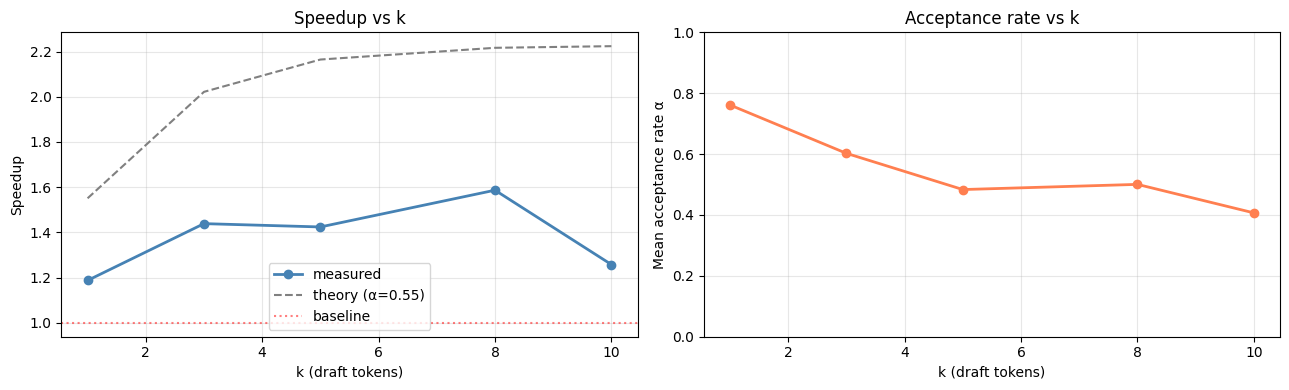

In [19]:
k_vals   = list(bench_results["speculative"].keys())
speedups = [bench_results["speculative"][k]["speedup"]    for k in k_vals]
alphas   = [bench_results["speculative"][k]["mean_alpha"] for k in k_vals]

# Theoretical speedup curve: E[tokens/pass] = (1 - α^(k+1)) / (1 - α)
# normalised by 1 (baseline) — gives expected speedup assuming target dominates runtime
def theoretical_speedup(k, alpha):
    if abs(1 - alpha) < 1e-9:
        return k + 1
    return (1 - alpha ** (k + 1)) / (1 - alpha)

mean_alpha = np.mean(alphas)
theory = [theoretical_speedup(k, mean_alpha) for k in k_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(k_vals, speedups, "o-", color="steelblue", linewidth=2, label="measured")
ax1.plot(k_vals, theory,   "--", color="gray",      linewidth=1.5, label=f"theory (α={mean_alpha:.2f})")
ax1.axhline(1.0, linestyle=":", color="red", alpha=0.5, label="baseline")
ax1.set_xlabel("k (draft tokens)"); ax1.set_ylabel("Speedup")
ax1.set_title("Speedup vs k"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(k_vals, alphas, "o-", color="coral", linewidth=2)
ax2.set_xlabel("k (draft tokens)"); ax2.set_ylabel("Mean acceptance rate α")
ax2.set_title("Acceptance rate vs k")
ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Note: measured speedup < theoretical because the draft model also has a cost.
# Theoretical assumes draft is free — valid when draft << target.

---
## Stage 4 — Code Edit Workload

Edit-style outputs contain large spans of unchanged code. The draft model
predicts these verbatim lines easily → acceptance rate α is much higher
than on open-ended generation → larger practical speedup.

In [20]:
edit_prompts = [
    """Complete this diff:
-    def forward(self, x):
-        return self.linear(x)
+    def forward(self, x: torch.Tensor) -> torch.Tensor:
+""",
    """Continue this Python function by adding type hints:
def compute_loss(predictions, targets, weights=None):
    # Add type annotations to this function
    def compute_loss(""",
]

open_ended_prompts = [
    "Explain the intuition behind attention mechanisms in transformers:",
    "Write a short story about a robot learning to paint:",
]

def measure_alpha_by_domain(prompts, label, k=5, max_new_tokens=60):
    alphas = []
    for prompt in prompts:
        ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        _, stats = speculative_decode(draft_model, target_model, ids, k=k, max_new_tokens=max_new_tokens)
        alphas.append(stats.mean_acceptance_rate)
    print(f"{label}: mean α = {np.mean(alphas):.2%}  per prompt: {[f'{a:.0%}' for a in alphas]}")
    return alphas

edit_alphas      = measure_alpha_by_domain(edit_prompts,      "Edit-style ")
open_alphas      = measure_alpha_by_domain(open_ended_prompts, "Open-ended ")

Edit-style : mean α = 50.56%  per prompt: ['51%', '50%']
Open-ended : mean α = 59.58%  per prompt: ['69%', '51%']


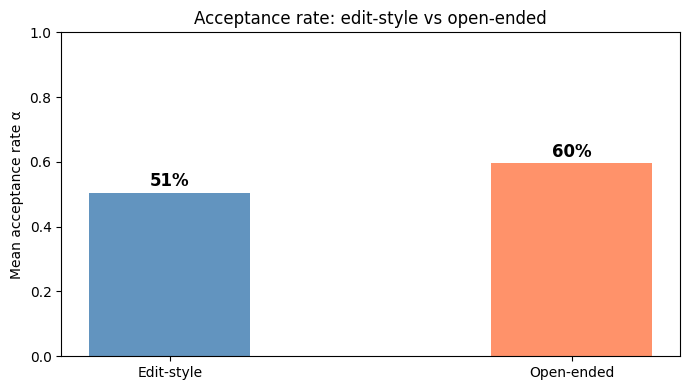

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
categories = ["Edit-style", "Open-ended"]
means  = [np.mean(edit_alphas), np.mean(open_alphas)]
colors = ["steelblue", "coral"]

bars = ax.bar(categories, means, color=colors, alpha=0.85, width=0.4)
ax.set_ylabel("Mean acceptance rate α")
ax.set_title("Acceptance rate: edit-style vs open-ended")
ax.set_ylim(0, 1)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f"{v:.0%}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Appendix — Why the Math Works

The acceptance criterion `min(1, p_t / p_d)` comes directly from **rejection sampling**.

**Claim:** the distribution of each accepted token is exactly `p_target`.

**Proof sketch** for token `x`:

```
P(output = x) = P(x drawn from draft) × P(x accepted)
              + P(x drawn from correction)

             = p_d(x) × min(1, p_t(x)/p_d(x))
             + P(rejection at some earlier pos) × p_corrected(x)
```

The correction distribution `normalize(max(0, p_t - p_d))` handles exactly
the probability mass that `p_draft` under-allocated to `x` relative to `p_target`.
The two terms sum to `p_target(x)`. ∎

**Implication:** you get **exactly** target-model quality, not an approximation.
The only thing you trade is compute on the draft side.

---
## Extension Exercises

**1. Temperature sampling**  
Extend `draft_autoregressive` to sample from `Categorical(softmax(logits/T))`  
instead of argmax. Update rejection criterion accordingly.

**2. Dynamic k**  
Track rolling acceptance rate. If `α > 0.8` → increase k. If `α < 0.5` → decrease k.  
Plot k over time for different prompt types.

**3. Tree speculative decoding**  
Instead of one draft sequence, generate a beam of width `b` with depth `d`.  
Target scores all `b×d` nodes in one pass using a tree attention mask.

**4. Medusa heads**  
Attach `k` extra linear heads to the draft model, each predicting token at offset `+i`.  
No separate draft model needed — all heads run in one forward pass.

**5. Code model pair**  
Swap in `codegen-350M` (draft) + `codegen-2B` (target).  
Repeat Stage 4 acceptance rate analysis with real code edit prompts.